In [1]:
from utils.diffusion_model import DDPMTrainer, TrainConfig
import scanpy as sc
import numpy as np


In [2]:
adata1 = sc.read_h5ad("./data/starmap/starmap_slice_1.h5ad")
adata2 = sc.read_h5ad("./data/starmap/starmap_slice_2.h5ad")
adata3 = sc.read_h5ad("./data/starmap/starmap_slice_3.h5ad")
adata4 = sc.read_h5ad("./data/starmap/starmap_slice_4.h5ad")
adata5 = sc.read_h5ad("./data/starmap/starmap_slice_5.h5ad")
adata6 = sc.read_h5ad("./data/starmap/starmap_slice_6.h5ad")
adata7 = sc.read_h5ad("./data/starmap/starmap_slice_7.h5ad")
adata8 = sc.read_h5ad("./data/starmap/starmap_slice_8.h5ad")
adata9 = sc.read_h5ad("./data/starmap/starmap_slice_9.h5ad")
adata = adata1.concatenate(adata3, adata4, adata5, adata6, adata7, adata8, adata9)


/tmp/ipykernel_95634/1995364315.py:10: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata1.concatenate(adata3, adata4, adata5, adata6, adata7, adata8, adata9)


In [3]:
coords_np = adata.obs[["x", "y", "z"]].to_numpy()

In [4]:
from utils.diffusion_model import TrainConfig, DDPMTrainer

cfg = TrainConfig()
trainer = DDPMTrainer(coords_np, cfg)

In [5]:
trainer.train()


Epoch 001 | loss 0.985800
Epoch 002 | loss 0.986068
Epoch 003 | loss 0.973011
Epoch 004 | loss 0.978240
Epoch 005 | loss 0.971950
Epoch 006 | loss 0.964407
Epoch 007 | loss 0.980897
Epoch 008 | loss 0.977860
Epoch 009 | loss 0.972693
Epoch 010 | loss 0.967293
Epoch 011 | loss 0.972016
Epoch 012 | loss 0.969500
Epoch 013 | loss 0.966800
Epoch 014 | loss 0.966848
Epoch 015 | loss 0.962407
Epoch 016 | loss 0.962523
Epoch 017 | loss 0.963803
Epoch 018 | loss 0.966262
Epoch 019 | loss 0.968846
Epoch 020 | loss 0.959836
Epoch 021 | loss 0.959250
Epoch 022 | loss 0.975850
Epoch 023 | loss 0.956408
Epoch 024 | loss 0.968291
Epoch 025 | loss 0.965028
Epoch 026 | loss 0.954704
Epoch 027 | loss 0.961716
Epoch 028 | loss 0.952685
Epoch 029 | loss 0.951877
Epoch 030 | loss 0.962194
Epoch 031 | loss 0.960992
Epoch 032 | loss 0.955113
Epoch 033 | loss 0.960338
Epoch 034 | loss 0.952115
Epoch 035 | loss 0.957210
Epoch 036 | loss 0.955176
Epoch 037 | loss 0.953692
Epoch 038 | loss 0.960303
Epoch 039 | 

In [6]:
target_z = adata2.obs["z"].mean()
neighbor_slice_coords = adata3.obs[["x", "y", "z"]].to_numpy()
n_samples = adata2.shape[0]
xy_target = adata2.obs[["x", "y"]].to_numpy()
bw = 0.01 * np.std(neighbor_slice_coords[:, :2], axis=0).mean()

In [19]:
xy_guided = trainer.sample_with_guidance(
    n_samples=n_samples,
    z_world=target_z,
    neighbor_coords=neighbor_slice_coords,
    kde_bandwidth=bw,
    guidance_scale=20000.0,
    x_clip = 1.8,
    guidance_clip=1.0,
    debug=True,
    debug_every=10,
)

[guidance] t=0099 |grad_norm| median=0.000629 max=0.00296
[guidance] t=0090 |grad_norm| median=0.000603 max=0.00298
[guidance] t=0080 |grad_norm| median=0.000586 max=0.00293
[guidance] t=0070 |grad_norm| median=0.000598 max=0.00293
[guidance] t=0060 |grad_norm| median=0.000563 max=0.00292
[guidance] t=0050 |grad_norm| median=0.000557 max=0.00293
[guidance] t=0040 |grad_norm| median=0.000567 max=0.00293
[guidance] t=0030 |grad_norm| median=0.000576 max=0.00294
[guidance] t=0020 |grad_norm| median=0.000532 max=0.00296
[guidance] t=0010 |grad_norm| median=0.000541 max=0.00295
[guidance] t=0000 |grad_norm| median=0.000474 max=0.00295


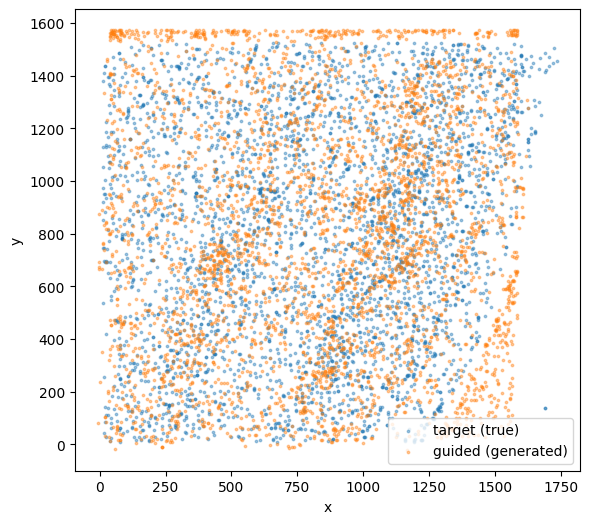

In [20]:
import matplotlib.pyplot as plt

# xy_target: (N,2) true target slice coords
# xy_guided: (M,2) generated coords

plt.figure(figsize=(6, 6))
plt.scatter(xy_target[:, 0], xy_target[:, 1], s=3, alpha=0.4, label="target (true)")
plt.scatter(xy_guided[:, 0], xy_guided[:, 1], s=3, alpha=0.4, label="guided (generated)")
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
xy_ung = trainer.sample(n_samples=n_samples, z_world=target_z)

print("ung mean/std:", xy_ung.mean(0), xy_ung.std(0))
print("gdd mean/std:", xy_guided.mean(0), xy_guided.std(0))

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from utils.diffusion_model import KDEMixture

xy_nbr = neighbor_slice_coords[:, :2].astype(np.float32)

# build KDEMixture exactly like in the sampler
kde = KDEMixture(xy_nbr, bandwidth=float(bw), z_factor=1.0)  # z_factor irrelevant for 2D

# grid to evaluate on (choose bounds from target+neighbor)
all_xy = np.vstack([xy_target.astype(np.float32), xy_nbr])
xmin, ymin = all_xy.min(axis=0)
xmax, ymax = all_xy.max(axis=0)

nx = ny = 200
xx, yy = np.meshgrid(np.linspace(xmin, xmax, nx), np.linspace(ymin, ymax, ny))
grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

# call KDEMixture forward: returns (density, grad_log_density)
with torch.no_grad():
    fvals, log_grad = kde(torch.tensor(grid), sample_frac=1.0)

F = fvals.cpu().numpy().reshape(ny, nx)

plt.figure(figsize=(6, 6))
plt.imshow(F, origin="lower", extent=[xmin, xmax, ymin, ymax], aspect="equal")
plt.colorbar(label="KDE density (unnormalized)")
plt.title("Neighbor slice KDEMixture density")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [ ]:
G = log_grad.cpu().numpy().reshape(ny, nx, 2)

step = 10  # fewer arrows -> clearer
U = G[::step, ::step, 0]
V = G[::step, ::step, 1]
X = xx[::step, ::step]
Y = yy[::step, ::step]

plt.figure(figsize=(6, 6))
plt.imshow(F, origin="lower", extent=[xmin, xmax, ymin, ymax], aspect="equal", alpha=0.85)
gain = 2000.0
plt.quiver(X, Y, gain*U, gain*V, color="white", scale_units="xy", scale=1, width=0.003)
plt.title("KDEMixture density + ∇log density (guidance)")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from utils.diffusion_model import KDEMixture

xy_nbr = neighbor_slice_coords[:, :2].astype(np.float32)

kde = KDEMixture(xy_nbr, bandwidth=float(bw), z_factor=1.0)

with torch.no_grad():
    xy_kde = kde.sample(n_samples).cpu().numpy().astype(np.float32)

plt.figure(figsize=(6, 6))
plt.scatter(xy_target[:, 0], xy_target[:, 1], s=3, alpha=0.35, label="target (true)")
plt.scatter(xy_kde[:, 0], xy_kde[:, 1], s=3, alpha=0.35, label="neighbor KDE samples")
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()